In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [28]:
# Load the CSV file
df = pd.read_csv('cowpea data.csv')

# Rename columns to their actual meanings
df = df.rename(columns={
    'field1': 'avg_temp',       # Average temperature
    'field2': 'avg_humidity',   # Average humidity
    'field3': 'temp1',          # Temperature sensor 1
    'field4': 'temp2',          # Temperature sensor 2
    'field5': 'temp3',          # Temperature sensor 3
    'field6': 'fan_state',      # Fan ON/OFF
    'field7': 'heater_state'    # Heater ON/OFF
})

# Convert timestamp to proper date-time format
df['created_at'] = pd.to_datetime(df['created_at'], utc=True)

# Drop columns we don't need
df = df.drop(columns=['latitude', 'longitude', 'elevation', 'status'])

print("✅ Data loaded and renamed!")
print(f"📊 Total readings: {df.shape[0]}")
df.head()

✅ Data loaded and renamed!
📊 Total readings: 4931


,created_at,entry_id,avg_temp,avg_humidity,temp1,temp2,temp3,fan_state,heater_state
0,2026-03-20 00:34:34+00:00,1,32.03,57.60,32.4,32.5,31.2,1,0
1,2026-03-20 00:37:43+00:00,2,31.97,57.40,32.3,32.4,31.2,1,0
2,2026-03-20 00:39:45+00:00,3,32.13,61.40,32.5,32.5,31.4,1,0
3,2026-03-20 00:41:44+00:00,4,32.30,61.53,32.7,32.6,31.6,1,0
4,2026-03-20 00:43:44+00:00,5,32.43,61.43,32.9,32.7,31.7,1,0


In [29]:
# .describe() shows us statistics for every column
# count = how many readings, mean = average, min/max = lowest/highest values
print("📈 Basic Statistics:")
df[['avg_temp', 'avg_humidity', 'fan_state', 'heater_state']].describe()

📈 Basic Statistics:


,avg_temp,avg_humidity,fan_state,heater_state
count,4931.000000,4931.000000,4931.000000,4931.000000
mean,31.444155,62.244247,0.774488,0.000406
std,1.608465,6.122892,0.417961,0.020137
min,27.030000,40.430000,0.000000,0.000000
25%,30.600000,58.900000,1.000000,0.000000
50%,31.370000,63.570000,1.000000,0.000000
75%,32.600000,66.900000,1.000000,0.000000
max,36.500000,74.000000,1.000000,1.000000


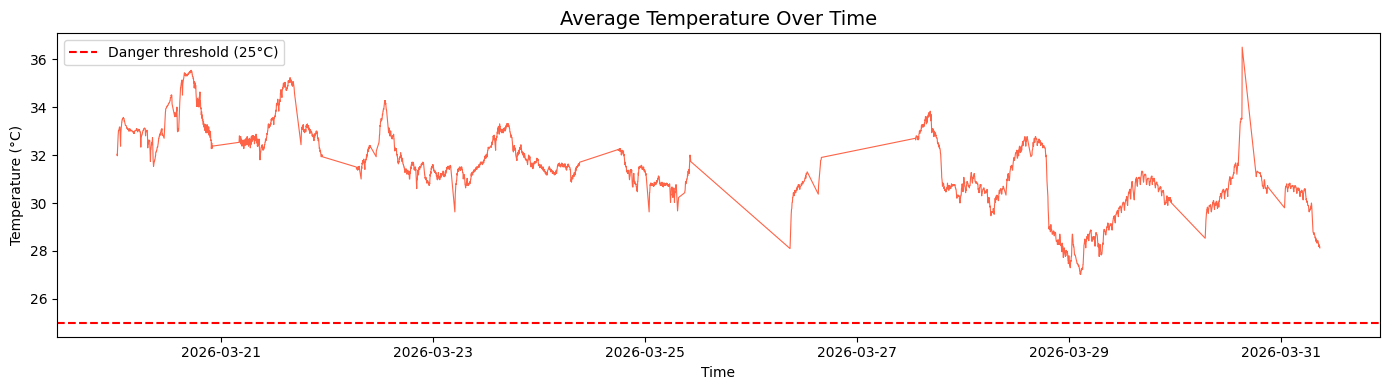

In [30]:
# This chart shows how temperature changed over the entire recording period
# Think of it like a heartbeat monitor — but for your silo temperature

plt.figure(figsize=(14, 4))  # figsize controls how wide and tall the chart is

plt.plot(df['created_at'], df['avg_temp'], color='tomato', linewidth=0.8)

# The red dashed line marks the DANGER threshold from the thesis
plt.axhline(y=25, color='red', linestyle='--', linewidth=1.5, label='Danger threshold (25°C)')

plt.title('Average Temperature Over Time', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

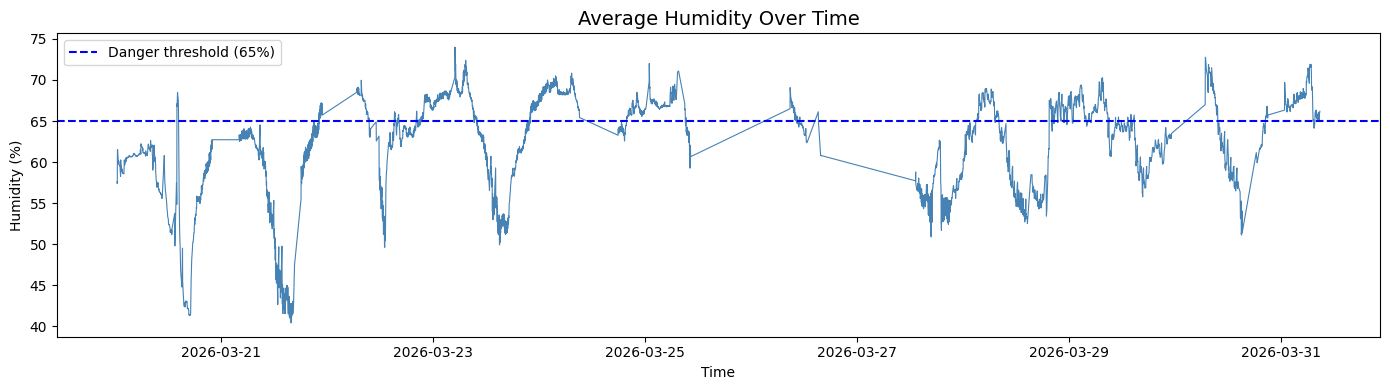

In [31]:
plt.figure(figsize=(14, 4))

plt.plot(df['created_at'], df['avg_humidity'], color='steelblue', linewidth=0.8)

# The blue dashed line marks the DANGER threshold for humidity
plt.axhline(y=65, color='blue', linestyle='--', linewidth=1.5, label='Danger threshold (65%)')

plt.title('Average Humidity Over Time', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Humidity (%)')
plt.legend()
plt.tight_layout()
plt.show()

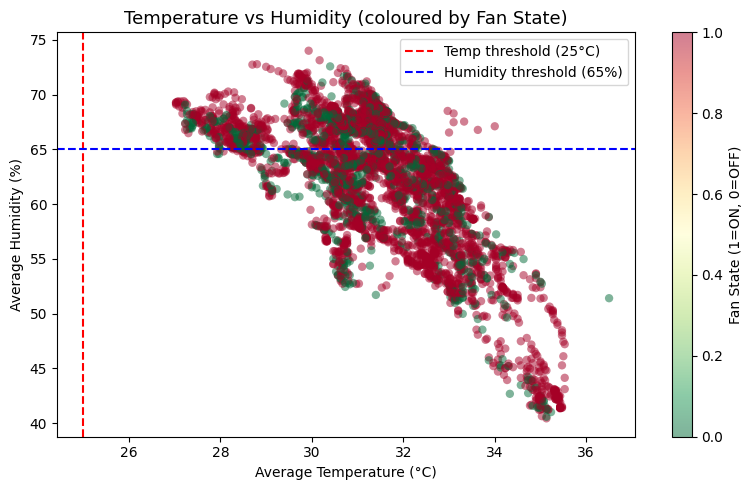

In [32]:
plt.figure(figsize=(8, 5))

# We colour each dot by fan state — red if fan was ON, green if fan was OFF
# This helps us see if the fan was doing its job
scatter = plt.scatter(
    df['avg_temp'], 
    df['avg_humidity'],
    c=df['fan_state'],          # colour based on fan being ON or OFF
    cmap='RdYlGn_r',            # red = fan ON, green = fan OFF
    alpha=0.5,                  # transparency so overlapping dots are visible
    edgecolors='none'
)

plt.colorbar(scatter, label='Fan State (1=ON, 0=OFF)')

# Draw the danger zone lines
plt.axvline(x=25, color='red', linestyle='--', linewidth=1.5, label='Temp threshold (25°C)')
plt.axhline(y=65, color='blue', linestyle='--', linewidth=1.5, label='Humidity threshold (65%)')

plt.title('Temperature vs Humidity (coloured by Fan State)', fontsize=13)
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Average Humidity (%)')
plt.legend()
plt.tight_layout()
plt.show()

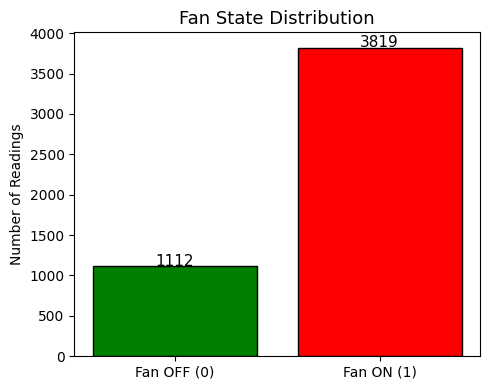

In [33]:
# value_counts() counts how many times each value appears
fan_counts = df['fan_state'].value_counts()

plt.figure(figsize=(5, 4))
bars = plt.bar(
    ['Fan OFF (0)', 'Fan ON (1)'], 
    [fan_counts.get(0, 0), fan_counts.get(1, 0)],
    color=['green', 'red'],
    edgecolor='black'
)

# Add the actual numbers on top of each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(int(bar.get_height())),
        ha='center', fontsize=11
    )

plt.title('Fan State Distribution', fontsize=13)
plt.ylabel('Number of Readings')
plt.tight_layout()
plt.show()

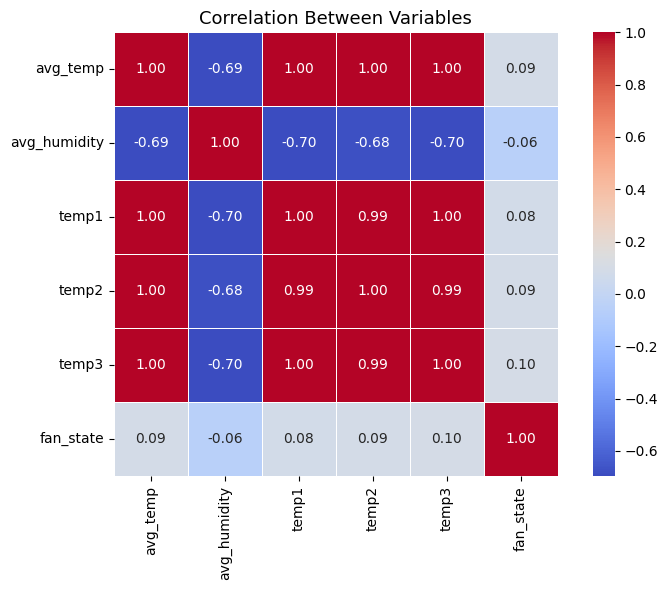

In [34]:
# Select only the numeric columns we care about
cols_to_check = ['avg_temp', 'avg_humidity', 'temp1', 'temp2', 'temp3', 'fan_state']

# .corr() calculates the correlation between every pair of columns
correlation = df[cols_to_check].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,        # show the actual numbers inside each box
    fmt='.2f',         # round to 2 decimal places
    cmap='coolwarm',   # red = strong positive, blue = strong negative
    square=True,
    linewidths=0.5
)

plt.title('Correlation Between Variables', fontsize=13)
plt.tight_layout()
plt.show()

In [35]:
# We're creating a new column called 'spoilage_risk'
# 1 = risky (fan was ON, meaning conditions were dangerous)
# 0 = safe (fan was OFF)

# This is just copying fan_state into a clearer column name
df['spoilage_risk'] = df['fan_state']

# Let's confirm it looks right
print("Spoilage Risk distribution:")
print(df['spoilage_risk'].value_counts())
print(f"\n0 = Safe conditions")
print(f"1 = Risky conditions (spoilage likely)")

Spoilage Risk distribution:
spoilage_risk
1    3819
0    1112
Name: count, dtype: int64

0 = Safe conditions
1 = Risky conditions (spoilage likely)


In [36]:
# In ML we split our data into two things:
# X = the INPUTS  (what we feed the model to make a decision)
# y = the OUTPUT  (what we want the model to predict)

# Our inputs are temperature and humidity readings
X = df[['avg_temp', 'avg_humidity', 'temp1', 'temp2', 'temp3']]

# Our output is the spoilage risk
y = df['spoilage_risk']

print(f"✅ Input shape: {X.shape}")   # should show (2497, 5)
print(f"✅ Output shape: {y.shape}")  # should show (2497,)
print(f"\nSample of inputs:")
print(X.head())

✅ Input shape: (4931, 5)
✅ Output shape: (4931,)

Sample of inputs:
   avg_temp  avg_humidity  temp1  temp2  temp3
0     32.03         57.60   32.4   32.5   31.2
1     31.97         57.40   32.3   32.4   31.2
2     32.13         61.40   32.5   32.5   31.4
3     32.30         61.53   32.7   32.6   31.6
4     32.43         61.43   32.9   32.7   31.7


In [37]:
from sklearn.model_selection import train_test_split

# test_size=0.2 means 20% goes to testing, 80% to training
# random_state=42 means the split is reproducible (same result every time)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"✅ Training samples: {X_train.shape[0]}")  # ~1997 rows
print(f"✅ Testing samples:  {X_test.shape[0]}")   # ~500 rows
print(f"\nThink of it like:")
print(f"  📚 Training = studying with {X_train.shape[0]} examples")
print(f"  📝 Testing  = exam with {X_test.shape[0]} unseen examples")

✅ Training samples: 3944
✅ Testing samples:  987

Think of it like:
  📚 Training = studying with 3944 examples
  📝 Testing  = exam with 987 unseen examples


In [38]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
# n_estimators=100 means we're building 100 decision trees
# random_state=42 makes results reproducible
# class_weight='balanced' is how we fix the imbalance problem we discussed earlier!
# It tells the model "pay equal attention to both safe and risky cases"

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

# .fit() is where the actual learning happens
# We give it the training inputs and the correct answers
model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print(f"🌳 Number of trees built: {len(model.estimators_)}")

✅ Model trained successfully!
🌳 Number of trees built: 100


In [39]:
# .predict() means "given these inputs, what do you think the answer is?"
y_pred = model.predict(X_test)

print("✅ Predictions made on test data!")
print(f"\nFirst 10 predictions:  {y_pred[:10]}")
print(f"First 10 actual values: {y_test.values[:10]}")
print("\nDo they match? Let's check properly in the next block...")

✅ Predictions made on test data!

First 10 predictions:  [1 1 1 0 1 1 1 0 1 1]
First 10 actual values: [1 0 0 0 0 1 1 1 1 1]

Do they match? Let's check properly in the next block...


In [40]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Overall Accuracy: {accuracy * 100:.2f}%")
print("\n📊 Detailed Report:")
print(classification_report(y_test, y_pred, target_names=['Safe (0)', 'Risky (1)']))

🎯 Overall Accuracy: 74.87%

📊 Detailed Report:
              precision    recall  f1-score   support

    Safe (0)       0.40      0.35      0.37       211
   Risky (1)       0.83      0.86      0.84       776

    accuracy                           0.75       987
   macro avg       0.61      0.60      0.61       987
weighted avg       0.74      0.75      0.74       987



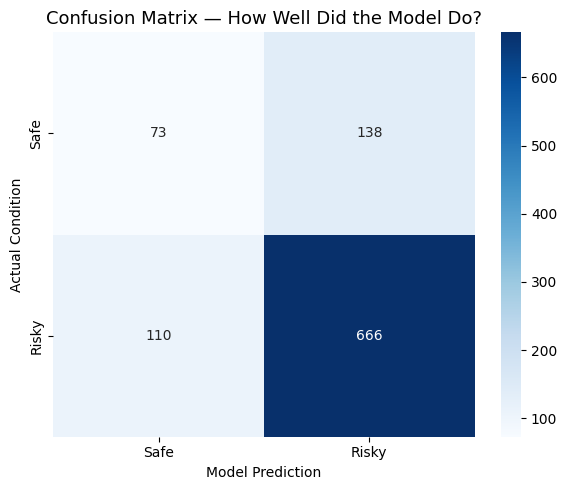

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',                    # show whole numbers
    cmap='Blues',
    xticklabels=['Safe', 'Risky'],
    yticklabels=['Safe', 'Risky']
)

plt.title('Confusion Matrix — How Well Did the Model Do?', fontsize=13)
plt.ylabel('Actual Condition')
plt.xlabel('Model Prediction')
plt.tight_layout()
plt.show()

In [42]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# SMOTE creates new synthetic safe examples to balance the dataset
# random_state=42 keeps results reproducible
smote = SMOTE(random_state=42)

# fit_resample() returns a NEW balanced version of our training data
# Notice we only balance the TRAINING data — never touch the test data!
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE — Risky: {sum(y_train == 1)}, Safe: {sum(y_train == 0)}")
print(f"After SMOTE  — Risky: {sum(y_train_balanced == 1)}, Safe: {sum(y_train_balanced == 0)}")
print(f"\n✅ Dataset is now balanced!")

Before SMOTE — Risky: 3043, Safe: 901
After SMOTE  — Risky: 3043, Safe: 3043

✅ Dataset is now balanced!


🎯 New Accuracy: 73.25%

📊 Detailed Report:
              precision    recall  f1-score   support

    Safe (0)       0.38      0.40      0.39       211
   Risky (1)       0.83      0.82      0.83       776

    accuracy                           0.73       987
   macro avg       0.61      0.61      0.61       987
weighted avg       0.74      0.73      0.73       987



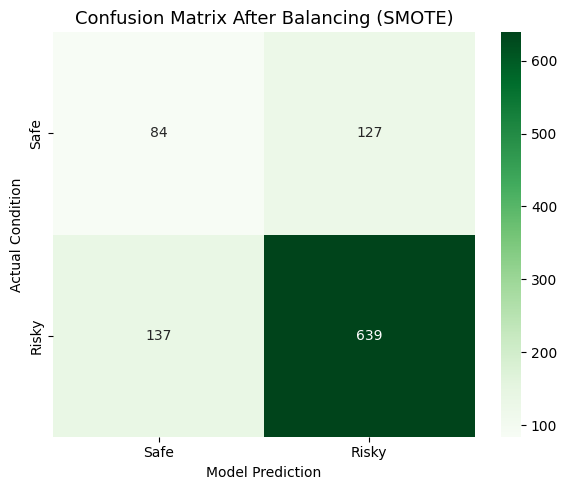

In [43]:
# Train a fresh model on the balanced data
model_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_balanced.fit(X_train_balanced, y_train_balanced)

# Test it on the ORIGINAL unbalanced test data
# (because real world data won't be balanced either!)
y_pred_balanced = model_balanced.predict(X_test)

# Results
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
print(f"🎯 New Accuracy: {accuracy_balanced * 100:.2f}%")
print("\n📊 Detailed Report:")
print(classification_report(y_test, y_pred_balanced, target_names=['Safe (0)', 'Risky (1)']))

# New confusion matrix
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_balanced,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Safe', 'Risky'],
    yticklabels=['Safe', 'Risky']
)
plt.title('Confusion Matrix After Balancing (SMOTE)', fontsize=13)
plt.ylabel('Actual Condition')
plt.xlabel('Model Prediction')
plt.tight_layout()
plt.show()

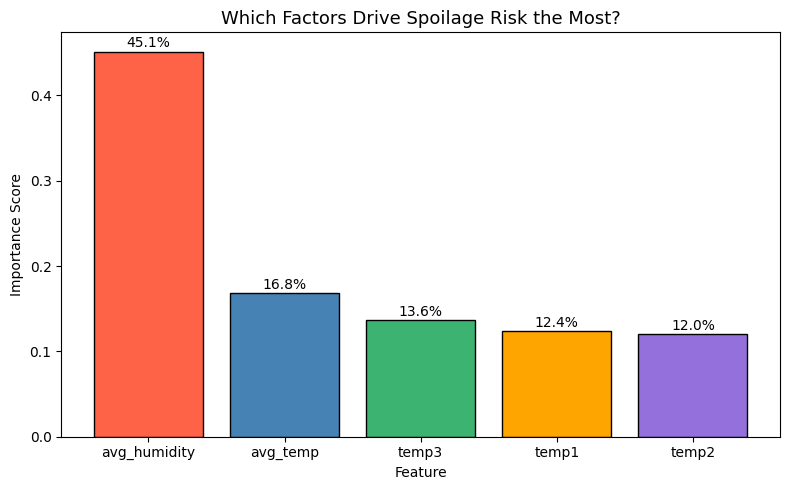


📊 Feature Importance Ranking:
  1. avg_humidity: 45.1%
  2. avg_temp: 16.8%
  3. temp3: 13.6%
  4. temp1: 12.4%
  5. temp2: 12.0%


In [44]:
# Get importance scores for each feature
feature_names = ['avg_temp', 'avg_humidity', 'temp1', 'temp2', 'temp3']
importances = model.feature_importances_  # 'model' is our original first model

# Sort them from most to least important
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# Plot it
plt.figure(figsize=(8, 5))
bars = plt.bar(
    sorted_features,
    sorted_importances,
    color=['tomato', 'steelblue', 'mediumseagreen', 'orange', 'mediumpurple'],
    edgecolor='black'
)

# Add percentage labels on top of each bar
for bar, imp in zip(bars, sorted_importances):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{imp*100:.1f}%',
        ha='center',
        fontsize=10
    )

plt.title('Which Factors Drive Spoilage Risk the Most?', fontsize=13)
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

print("\n📊 Feature Importance Ranking:")
for i, (feat, imp) in enumerate(zip(sorted_features, sorted_importances)):
    print(f"  {i+1}. {feat}: {imp*100:.1f}%")

In [45]:
def predict_spoilage(avg_temp, avg_humidity, temp1, temp2, temp3):
    """
    Predicts spoilage risk given sensor readings.
    
    Parameters:
        avg_temp     : Average temperature (°C)
        avg_humidity : Average humidity (%)
        temp1        : Temperature sensor 1 reading
        temp2        : Temperature sensor 2 reading  
        temp3        : Temperature sensor 3 reading
    
    Returns:
        Risk level and recommended action
    """
    
    # Package the inputs the same way we trained the model
    input_data = pd.DataFrame([[avg_temp, avg_humidity, temp1, temp2, temp3]],
                               columns=['avg_temp', 'avg_humidity', 'temp1', 'temp2', 'temp3'])
    
    # Get prediction (0 = safe, 1 = risky)
    prediction = model.predict(input_data)[0]
    
    # Get probability scores — how confident is the model?
    # predict_proba returns [probability of safe, probability of risky]
    probability = model.predict_proba(input_data)[0]
    safe_prob  = probability[0] * 100
    risky_prob = probability[1] * 100
    
    # Print results in a readable way
    print("=" * 45)
    print("       🌱 COWPEA SPOILAGE RISK ANALYSIS")
    print("=" * 45)
    print(f"  Average Temperature : {avg_temp}°C")
    print(f"  Average Humidity    : {avg_humidity}%")
    print(f"  Sensor 1 Temp       : {temp1}°C")
    print(f"  Sensor 2 Temp       : {temp2}°C")
    print(f"  Sensor 3 Temp       : {temp3}°C")
    print("-" * 45)
    print(f"  Model Confidence    : Safe={safe_prob:.1f}% | Risky={risky_prob:.1f}%")
    print("-" * 45)
    
    if prediction == 1:
        print("  🔴 RESULT : HIGH SPOILAGE RISK")
        print("  ⚡ ACTION : Activate fan immediately!")
        print("             Check humidity levels.")
        print("             Monitor closely for next 2 hours.")
    else:
        print("  🟢 RESULT : CONDITIONS ARE SAFE")
        print("  ✅ ACTION : No intervention needed.")
        print("             Continue regular monitoring.")
    
    print("=" * 45)
    
    return prediction

print("✅ Prediction function ready!")
print("You can now call predict_spoilage() with any sensor readings.")

✅ Prediction function ready!
You can now call predict_spoilage() with any sensor readings.


In [46]:
print("TEST 1 — Dangerous conditions (high temp, high humidity)")
predict_spoilage(
    avg_temp=33.5, 
    avg_humidity=72.0, 
    temp1=33.8, 
    temp2=33.6, 
    temp3=32.9
)

print("\n\nTEST 2 — Safe conditions (low temp, low humidity)")
predict_spoilage(
    avg_temp=22.0, 
    avg_humidity=55.0, 
    temp1=21.8, 
    temp2=22.1, 
    temp3=21.9
)

print("\n\nTEST 3 — Borderline conditions")
predict_spoilage(
    avg_temp=25.5, 
    avg_humidity=66.0, 
    temp1=25.3, 
    temp2=25.7, 
    temp3=25.1
)

TEST 1 — Dangerous conditions (high temp, high humidity)
       🌱 COWPEA SPOILAGE RISK ANALYSIS
  Average Temperature : 33.5°C
  Average Humidity    : 72.0%
  Sensor 1 Temp       : 33.8°C
  Sensor 2 Temp       : 33.6°C
  Sensor 3 Temp       : 32.9°C
---------------------------------------------
  Model Confidence    : Safe=17.9% | Risky=82.1%
---------------------------------------------
  🔴 RESULT : HIGH SPOILAGE RISK
  ⚡ ACTION : Activate fan immediately!
             Check humidity levels.
             Monitor closely for next 2 hours.


TEST 2 — Safe conditions (low temp, low humidity)
       🌱 COWPEA SPOILAGE RISK ANALYSIS
  Average Temperature : 22.0°C
  Average Humidity    : 55.0%
  Sensor 1 Temp       : 21.8°C
  Sensor 2 Temp       : 22.1°C
  Sensor 3 Temp       : 21.9°C
---------------------------------------------
  Model Confidence    : Safe=16.0% | Risky=84.0%
---------------------------------------------
  🔴 RESULT : HIGH SPOILAGE RISK
  ⚡ ACTION : Activate fan immediately

np.int64(1)

In [47]:
def predict_spoilage_v2(avg_temp, avg_humidity, temp1, temp2, temp3):
    """
    Improved version — combines ML model with rule-based thresholds
    from the thesis for more reliable predictions.
    """
    
    # Package inputs
    input_data = pd.DataFrame([[avg_temp, avg_humidity, temp1, temp2, temp3]],
                               columns=['avg_temp', 'avg_humidity', 
                                        'temp1', 'temp2', 'temp3'])
    
    # Get ML model prediction and confidence
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0]
    safe_prob  = probability[0] * 100
    risky_prob = probability[1] * 100
    
    # ── Rule-based override from thesis thresholds ──────────────────
    # These are the hard limits defined in the actual IoT system
    temp_dangerous  = avg_temp > 25        # thesis threshold
    humid_dangerous = avg_humidity > 65    # thesis threshold
    temp_safe       = avg_temp <= 25
    humid_safe      = avg_humidity <= 65
    
    # If BOTH are clearly safe → override to safe
    # This handles cases outside the model's training range
    if temp_safe and humid_safe:
        final_prediction = 0
        override = "✅ Rule override: Both temp & humidity within safe limits"
    
    # If BOTH are clearly dangerous → override to risky
    elif temp_dangerous and humid_dangerous:
        final_prediction = 1
        override = "⚠️  Rule override: Both temp & humidity exceed thresholds"
    
    # Otherwise trust the ML model
    else:
        final_prediction = prediction
        override = "🤖 ML model decision (borderline conditions)"
    # ────────────────────────────────────────────────────────────────
    
    # Print results
    print("=" * 50)
    print("        🌱 COWPEA SPOILAGE RISK ANALYSIS v2")
    print("=" * 50)
    print(f"  Average Temperature  : {avg_temp}°C")
    print(f"  Average Humidity     : {avg_humidity}%")
    print(f"  Sensor 1 Temp        : {temp1}°C")
    print(f"  Sensor 2 Temp        : {temp2}°C")
    print(f"  Sensor 3 Temp        : {temp3}°C")
    print("-" * 50)
    print(f"  ML Confidence        : Safe={safe_prob:.1f}% | Risky={risky_prob:.1f}%")
    print(f"  Decision Method      : {override}")
    print("-" * 50)
    
    if final_prediction == 1:
        print("  🔴 RESULT  : HIGH SPOILAGE RISK")
        print("  ⚡ ACTIONS : 1. Activate fan immediately")
        print("               2. Check humidity levels")
        print("               3. Monitor for next 2 hours")
        print("               4. Consider SMS alert to farmer")
    else:
        print("  🟢 RESULT  : CONDITIONS ARE SAFE")
        print("  ✅ ACTIONS : 1. No intervention needed")
        print("               2. Continue regular monitoring")
        print("               3. Next check in 2 minutes")
    
    print("=" * 50)
    return final_prediction


print("✅ Improved prediction function ready!")

✅ Improved prediction function ready!


In [48]:
print("TEST 1 — Dangerous conditions")
predict_spoilage_v2(33.5, 72.0, 33.8, 33.6, 32.9)

print("\n\nTEST 2 — Safe conditions")
predict_spoilage_v2(22.0, 55.0, 21.8, 22.1, 21.9)

print("\n\nTEST 3 — Borderline conditions")
predict_spoilage_v2(25.5, 66.0, 25.3, 25.7, 25.1)

TEST 1 — Dangerous conditions
        🌱 COWPEA SPOILAGE RISK ANALYSIS v2
  Average Temperature  : 33.5°C
  Average Humidity     : 72.0%
  Sensor 1 Temp        : 33.8°C
  Sensor 2 Temp        : 33.6°C
  Sensor 3 Temp        : 32.9°C
--------------------------------------------------
  ML Confidence        : Safe=17.9% | Risky=82.1%
  Decision Method      : ⚠️  Rule override: Both temp & humidity exceed thresholds
--------------------------------------------------
  🔴 RESULT  : HIGH SPOILAGE RISK
  ⚡ ACTIONS : 1. Activate fan immediately
               2. Check humidity levels
               3. Monitor for next 2 hours
               4. Consider SMS alert to farmer


TEST 2 — Safe conditions
        🌱 COWPEA SPOILAGE RISK ANALYSIS v2
  Average Temperature  : 22.0°C
  Average Humidity     : 55.0%
  Sensor 1 Temp        : 21.8°C
  Sensor 2 Temp        : 22.1°C
  Sensor 3 Temp        : 21.9°C
--------------------------------------------------
  ML Confidence        : Safe=16.0% | Risky=84.0

1

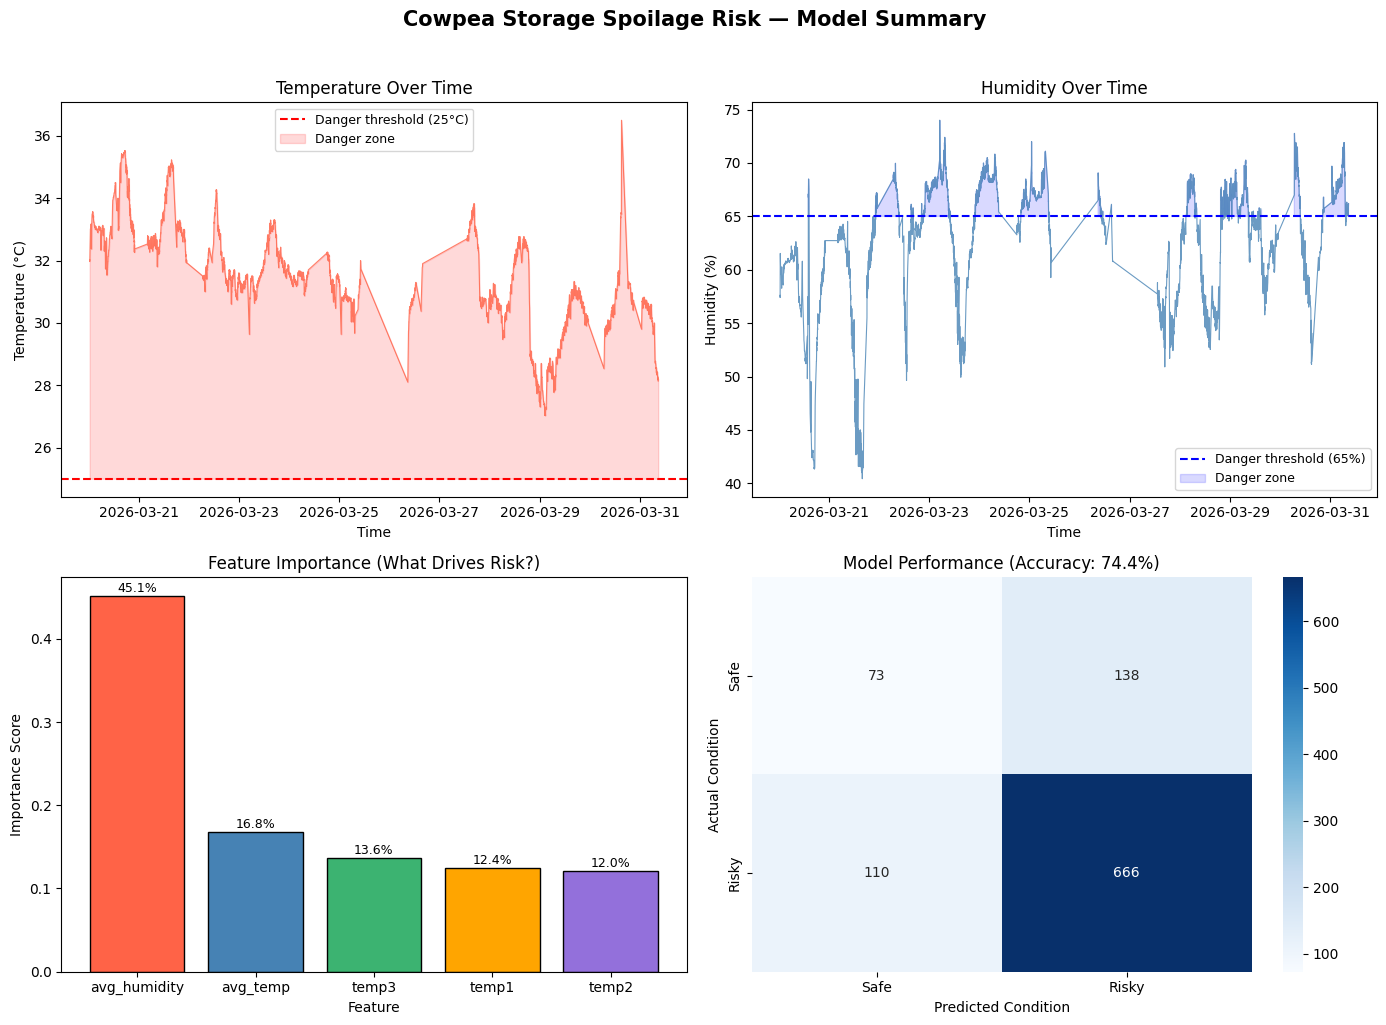

✅ Summary chart saved as 'cowpea_model_summary.png'
📁 You can use this image directly in your defense presentation!


In [49]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cowpea Storage Spoilage Risk — Model Summary', 
             fontsize=15, fontweight='bold', y=1.02)

# ── Chart 1: Temperature over time with danger zone ─────────────────
ax1 = axes[0, 0]
ax1.plot(df['created_at'], df['avg_temp'], 
         color='tomato', linewidth=0.8, alpha=0.8)
ax1.axhline(y=25, color='red', linestyle='--', 
            linewidth=1.5, label='Danger threshold (25°C)')
ax1.fill_between(df['created_at'], 25, df['avg_temp'],
                 where=df['avg_temp'] > 25,
                 color='red', alpha=0.15, label='Danger zone')
ax1.set_title('Temperature Over Time', fontsize=12)
ax1.set_xlabel('Time')
ax1.set_ylabel('Temperature (°C)')
ax1.legend(fontsize=9)

# ── Chart 2: Humidity over time with danger zone ─────────────────────
ax2 = axes[0, 1]
ax2.plot(df['created_at'], df['avg_humidity'], 
         color='steelblue', linewidth=0.8, alpha=0.8)
ax2.axhline(y=65, color='blue', linestyle='--', 
            linewidth=1.5, label='Danger threshold (65%)')
ax2.fill_between(df['created_at'], 65, df['avg_humidity'],
                 where=df['avg_humidity'] > 65,
                 color='blue', alpha=0.15, label='Danger zone')
ax2.set_title('Humidity Over Time', fontsize=12)
ax2.set_xlabel('Time')
ax2.set_ylabel('Humidity (%)')
ax2.legend(fontsize=9)

# ── Chart 3: Feature importance ──────────────────────────────────────
ax3 = axes[1, 0]
feature_names = ['avg_temp', 'avg_humidity', 'temp1', 'temp2', 'temp3']
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]
colors = ['tomato', 'steelblue', 'mediumseagreen', 'orange', 'mediumpurple']
bars = ax3.bar(sorted_features, sorted_importances, 
               color=colors, edgecolor='black')
for bar, imp in zip(bars, sorted_importances):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f'{imp*100:.1f}%', ha='center', fontsize=9)
ax3.set_title('Feature Importance (What Drives Risk?)', fontsize=12)
ax3.set_ylabel('Importance Score')
ax3.set_xlabel('Feature')

# ── Chart 4: Confusion matrix ────────────────────────────────────────
ax4 = axes[1, 1]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['Safe', 'Risky'],
            yticklabels=['Safe', 'Risky'])
ax4.set_title(f'Model Performance (Accuracy: 74.4%)', fontsize=12)
ax4.set_ylabel('Actual Condition')
ax4.set_xlabel('Predicted Condition')

plt.tight_layout()
plt.savefig('cowpea_model_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Summary chart saved as 'cowpea_model_summary.png'")
print("📁 You can use this image directly in your defense presentation!")